In [1]:
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import collections, re
import seaborn as sns

In [2]:
data = pd.read_csv("final_defesas_2006a2024.csv")

In [3]:
data["orientador_genero"].value_counts()

orientador_genero
Masculino    935
Feminino      92
sem orcid      1
Name: count, dtype: int64

<Axes: xlabel='count', ylabel='ano'>

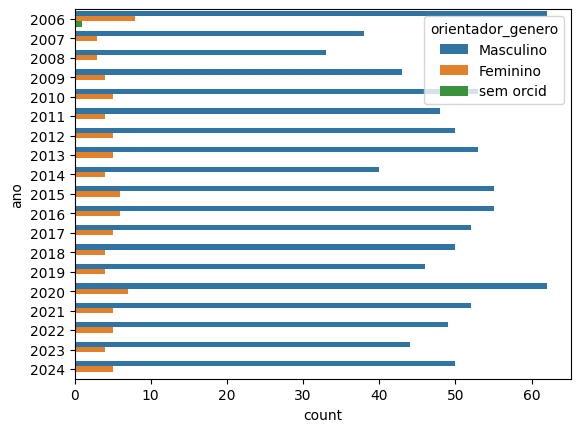

In [3]:
sns.countplot(data=data, y="ano", hue="orientador_genero")

## Criação de nós

In [4]:
padrao_avaliadores = 'avaliador\d$'
avaliadores = [col for col in data.columns if re.search(padrao_avaliadores, col)]
avaliadores.append("orientador")

In [5]:
grafo_defesas = nx.MultiDiGraph()
# grafo_defesas = nx.DiGraph()
n_banca = 0
for col in avaliadores:
    if "_" in col: continue
    if col == "ano": continue
    # if "orientador" not in "col"
    for index, url in zip(data[col].index, data[col]):
        if url != url: continue
        elif url == "sem orcid": continue
        grafo_defesas.add_node(
                              node_for_adding=url.split("/")[-1],
                              nome=data.at[index, f"{col}_nome"],
                              filiacao=data.at[index, f"{col}_filiação"],
                              genero=data.at[index, f"{col}_genero"],
                              )
    n_banca -=- 1

In [48]:
# Exemplo de nó:
grafo_defesas.nodes["0000-0002-8803-0401"]

{'nome': 'Rodolfo Azevedo', 'filiacao': 'UNICAMP', 'genero': 'Masculino'}

## Criação de arestas (arestas representam colaborações em defesas de mestrado, mestrado profissional ou doutorado)

In [6]:
for row in data.iterrows():
    # print(row[0], row[1]["orientador"])
    # break
    # a.add_edge(row[1]["orientador"], row[1]["avaliador1"])
    if row[1]["orientador"] != row[1]["orientador"]: continue
    if row[1]["orientador"] == "sem orcid": continue
    orcid_orient = row[1]["orientador"].split("/")[-1]
    for i in range(1, n_banca):
        if row[1][f"avaliador{i}"] != row[1][f"avaliador{i}"]: continue
        if row[1][f"avaliador{i}"] == "sem orcid": continue
        # if "Eliane Martins" == row[1][f"avaliador{i}_nome"].split("/")[-1]: print("ola_aval")
        # if "Eliane Martins" == row[1][f"orientador_nome"].split("/")[-1]: print("ola_orient")
        orcid_aval = row[1][f"avaliador{i}"].split("/")[-1]
        # if grafo_defesas.has_edge(orcid_orient, orcid_aval):
        #     grafo_defesas[orcid_orient][orcid_aval]["qtd"] -=- 1
        #     continue
        grafo_defesas.add_edge(orcid_orient, orcid_aval, qtd=1, ano=row[1]["ano"])
        ## aresta direcionada: orientadora/orientador -> avaliador/avaliadora
        # grafo_defesas.add_(orcid_orient, orcid_aval, qtd=1)
edge_widths = []
# for p1, p2 in grafo_defesas.edges:
#     edge_widths.append(1 * grafo_defesas[p1][p2]["qtd"])

## Cálculos dos graus máximo e mínimo

In [8]:
max_degree_in = 0
max_degree_out = 0
for no, degree in grafo_defesas.in_degree():
    if degree > max_degree_in:
        max_degree_in = degree
max_degree_person_in = [no for no, degree in grafo_defesas.in_degree() if degree == max_degree_in]

for no, degree in grafo_defesas.out_degree():
    if degree > max_degree_out:
        max_degree_out = degree
max_degree_person_out = [no for no, degree in grafo_defesas.out_degree() if degree == max_degree_out]

max_degree = 0
for no, degree in grafo_defesas.degree():
    if degree > max_degree:
        max_degree = degree
max_degree_person = [no for no, degree in grafo_defesas.degree() if degree == max_degree]

In [9]:
print(f"Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)")
for person in max_degree_person_out:
    print(grafo_defesas.nodes[person], f"Qtd de orientações: {grafo_defesas.out_degree[person]}")

Pessoa(s) com maior quantidade de orientações (maior grau de SAÍDA)
{'nome': 'Ricardo Torres', 'filiacao': 'Universidade Estadual de Campinas', 'genero': 'Masculino'} Qtd de orientações: 125


In [10]:
print(f"Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)")
for person in max_degree_person_in:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.in_degree[person]}")

Pessoa(s) com maior quantidade de avaliações (maior grau de ENTRADA)
{'nome': 'Helio Pedrini', 'filiacao': 'University of Campinas', 'genero': 'Masculino'} Qtd de avaliações: 69


In [11]:
print(f"Pessoa(s) com maior quantidade de colaborações (maior grau)")
for person in max_degree_person:
    print(grafo_defesas.nodes[person], f"Qtd de avaliações: {grafo_defesas.degree[person]}")

Pessoa(s) com maior quantidade de colaborações (maior grau)
{'nome': 'Helio Pedrini', 'filiacao': 'University of Campinas', 'genero': 'Masculino'} Qtd de avaliações: 190


### Gráfico log-log com graus de saída (orientação->avaliação)

In [12]:
degree_sequence = [d for _, d in grafo_defesas.out_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

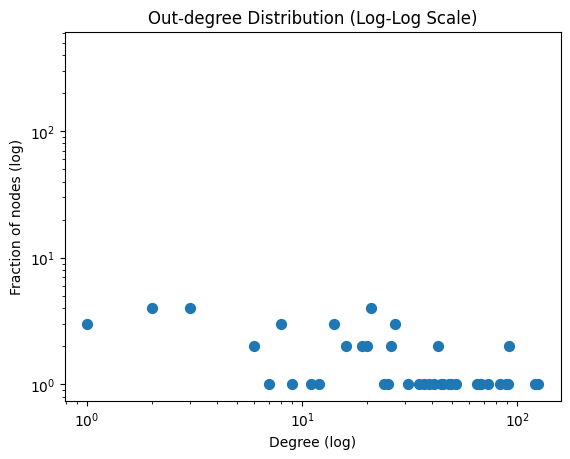

In [13]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("Out-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

#### Separando por gênero

In [21]:
genero = "Feminino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]

In [22]:
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

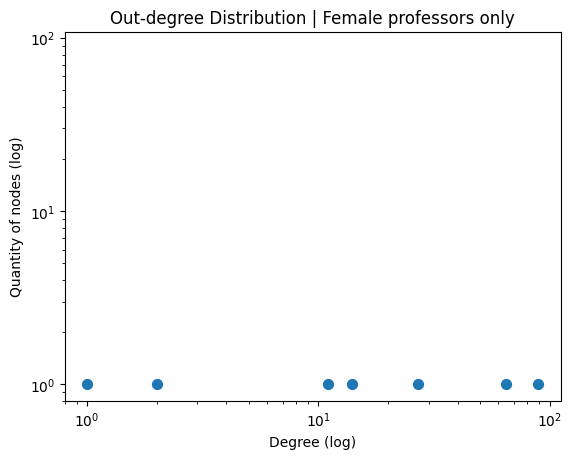

In [24]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Quantity of nodes (log)")
plt.title("Out-degree Distribution | Female professors only")
# plt.show()
plt.show()

In [25]:
genero = "Masculino"
grafo_defesas_genero = [x for x, y in grafo_defesas.nodes(data=True) if y["genero"] == genero]

In [26]:
degree_sequence = [d for person, d in grafo_defesas.out_degree() if person in grafo_defesas_genero]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

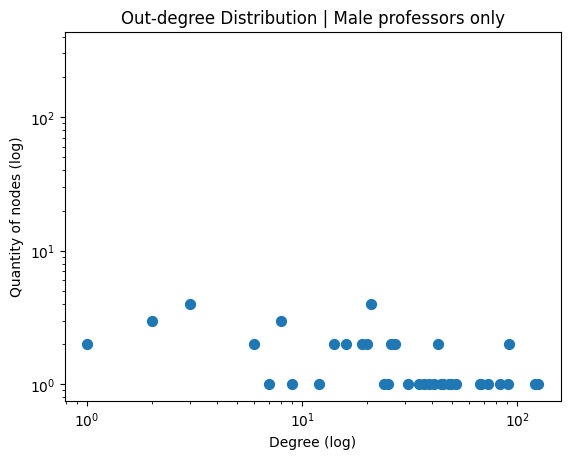

In [27]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Quantity of nodes (log)")
plt.title("Out-degree Distribution | Male professors only")
# plt.show()
plt.show()

### Gráfico log-log com graus de entrada (avaliação<-orientação)

In [35]:
degree_sequence = [d for _, d in grafo_defesas.in_degree()]  # list of degrees
gender_sequence = ["<" if grafo_defesas.nodes[v]["genero"] == "Masculino" else ">" for v, _ in grafo_defesas.out_degree()]  # list of degrees
degree_count = collections.Counter(degree_sequence)
deg, cnt = zip(*sorted(degree_count.items()))
# _, shape = zip(*sorted(node_shape.items()))

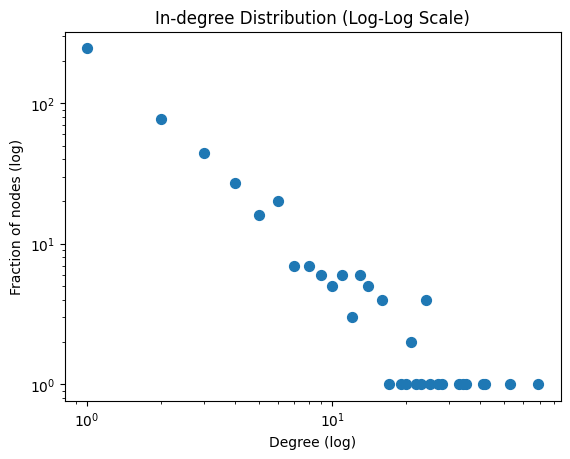

In [38]:
fig, ax = plt.subplots()
for deg, cnt in sorted(degree_count.items()):
    ax.scatter(deg, cnt, s=50, color="#1f78b4")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Degree (log)")
plt.ylabel("Fraction of nodes (log)")
plt.title("In-degree Distribution (Log-Log Scale)")
# plt.show()
plt.show()

## Contagem de nós e links

In [59]:
print(f"Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): {len(grafo_defesas.nodes)}")

Quantidade de nós (cada nó representa uma professora/professor que participou de uma banca orientando ou avaliando): 514


In [60]:
print(f"Quantidade de links (cada link representa uma colaboração entre professores em uma banca): {len(grafo_defesas.edges)}")

Quantidade de links (cada link representa uma colaboração entre professores em uma banca): 1989


In [78]:
colabs = pd.DataFrame(columns=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())],
                      index=[grafo_defesas.nodes[orcid]["nome"] for orcid in list(grafo_defesas.nodes.keys())])
colabs.fillna(0, inplace=True)
colabs

/tmp/ipykernel_8316/2668339885.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  colabs.fillna(0, inplace=True)


,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
Rodolfo Azevedo,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Velho,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Célio Albuquerque,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Neucimar Leite,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Luiz Eduardo Buzato,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"AMORIM, Raul Reis",0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Torsten Braun,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Antonio Carlos Rodrigues de Amorim,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Gastão Campos,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [80]:
links_por_ano = collections.defaultdict(int)
for edge in grafo_defesas.edges:
    colabs.at[grafo_defesas.nodes[edge[0]]["nome"], grafo_defesas.nodes[edge[1]]["nome"]] -=- 1

In [82]:
colabs.describe()

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"
count,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,514.000000,...,514.000000,514.000000,514.000000,514.000000,514.000000,514.0,514.0,514.0,514.0,514.0
mean,0.042802,0.001946,0.005837,0.027237,0.036965,0.005837,0.011673,0.005837,0.003891,0.005837,...,0.001946,0.001946,0.001946,0.001946,0.001946,0.0,0.0,0.0,0.0,0.0
std,0.361550,0.044108,0.098552,0.329270,0.364875,0.098552,0.186952,0.132324,0.088216,0.132324,...,0.044108,0.044108,0.044108,0.044108,0.044108,0.0,0.0,0.0,0.0,0.0
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
max,5.000000,1.000000,2.000000,6.000000,6.000000,2.000000,4.000000,3.000000,2.000000,3.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.0,0.0,0.0,0.0,0.0


In [84]:
colabs.values.max()

np.int64(26)

In [86]:
a

,Rodolfo Azevedo,Luiz Velho,Célio Albuquerque,Neucimar Leite,Luiz Eduardo Buzato,Eleri Cardozo,Carlos Maziero,Itana Gimenes,Silvia Vergilio,Djamel F Hadj Sadok,...,Fernando Paulovich,Lynda Hardman,Carlos Alberto Astudillo Trujillo,Sergio Salles-Filho,Yannis Velegrakis,"AMORIM, Raul Reis",Torsten Braun,Antonio Carlos Rodrigues de Amorim,Gastão Campos,"BULGARELI, J V"


In [88]:
a = colabs.where(colabs==colabs.values.max()).dropna(how="all").dropna(axis=1)
a.index, a.columns, colabs.values.max()

(Index(['Nelson L. S. da Fonseca'], dtype='object'),
 Index(['Edmundo Madeira'], dtype='object'),
 np.int64(26))